# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech
## Sistem Peringatan Dini Dua Titik Pantau — Jaya Jaya Institut

- **Nama:** Abyan Hisyam
- **Email:** abyanhisyamm@gmail.com
- **Id Dicoding:** Abyan Hisyam Al'ammar

---

## Business Understanding

**Jaya Jaya Institut** adalah perguruan tinggi yang berdiri sejak tahun 2000 dengan reputasi lulusan
yang baik. Namun dari 4.424 mahasiswa dalam catatan historisnya, **1.421 orang (32,1%) berhenti
sebelum lulus**.

Yang membuat masalah ini sulit ditangani bukan hanya besarnya angka, melainkan **waktunya**.
Institusi baru mengetahui seorang mahasiswa berhenti ketika surat pengunduran diri masuk — saat itu
seluruh pilihan intervensi sudah tertutup. Padahal proses menuju *dropout* berlangsung bertahap dan
meninggalkan jejak dalam data akademik jauh sebelum keputusan berhenti diambil.

Karena itu proyek ini tidak berhenti pada pertanyaan *"siapa yang berisiko?"*, tetapi menambahkan
pertanyaan yang sama pentingnya: ***"kapan kita paling awal bisa tahu, dan apakah pengetahuan itu
masih cukup akurat untuk ditindaklanjuti?"***

### Permasalahan Bisnis

1. **Deteksi selalu terlambat.** Institusi bersifat reaktif; tidak ada mekanisme yang memberi sinyal
   di tengah masa studi ketika bimbingan masih bisa mengubah hasil.
2. **Tidak diketahui kapan titik pantau paling efektif.** Menunggu data dua semester memberi prediksi
   lebih akurat, tetapi memangkas waktu yang tersisa untuk bertindak. Sebaliknya memantau setelah satu
   semester memberi waktu lebih panjang dengan akurasi lebih rendah. *Trade-off* ini belum pernah
   diukur.
3. **Ambang batas peringatan ditentukan tanpa dasar ekonomi.** Menandai terlalu banyak mahasiswa
   membuang kapasitas tim bimbingan; menandai terlalu sedikit membuat institusi kehilangan mahasiswa.
   Belum ada perhitungan yang menyeimbangkan keduanya.
4. **Kapasitas bimbingan terbatas** sehingga dibutuhkan pemeringkatan prioritas, bukan sekadar daftar
   berisiko.

### Cakupan Proyek

1. **Data Understanding & EDA** — dengan penekanan pada **progresi antar-semester**: bagaimana posisi
   akademik mahasiswa berubah dari semester 1 ke semester 2, dan pola perubahan mana yang berujung
   pada *dropout*.
2. **Feature Engineering** — membentuk fitur turunan yang merepresentasikan *laju* dan *arah* performa
   (rasio kelulusan, selisih antar-semester, indeks tekanan finansial), bukan hanya nilai mentahnya.
3. **Data Preparation** — menyusun **dua set fitur terpisah** sesuai titik pantau: satu berisi hanya
   data yang benar-benar sudah tersedia di akhir semester 1, satu lagi lengkap dua semester.
4. **Modeling** — membandingkan tiga algoritma berbasis pohon dan melatih **dua model checkpoint**,
   masing-masing dituning dengan `RandomizedSearchCV`.
5. **Evaluation** — memilih ambang batas melalui **analisis biaya**, bukan berdasarkan tampilan
   grafik, lalu menguji seberapa peka keputusan itu terhadap asumsi biaya yang dipakai.
6. **Business Dashboard** — dashboard Metabase yang menggabungkan data historis **dan skor risiko
   hasil model**, sehingga manajemen melihat kondisi sekaligus prediksi dalam satu tempat.
7. **Deployment** — *prototype* Streamlit dengan pemilih titik pantau dan simulator *what-if*.

**Batasan:** data berasal dari satu institusi dan tidak memuat alasan berhenti, kondisi psikologis,
maupun catatan kehadiran. Model memberi peringkat risiko, bukan vonis, dan tidak boleh dipakai
sebagai dasar sanksi akademik.

### Persiapan

- **Sumber data:** [Students' Performance Dataset — Dicoding Academy](https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance)
  (UCI Machine Learning Repository, Realinho dkk., 2021).
- **Berkas:** `data.csv` — 4.424 baris, 37 kolom, delimiter `;`.

---

## Persiapan
### Menyiapkan library yang dibutuhkan

In [1]:
# Pengolahan data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     RandomizedSearchCV, StratifiedKFold)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, precision_recall_curve,
                             classification_report, confusion_matrix)
from scipy.stats import randint, uniform

# Utilitas
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='ticks')
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.25})

SEED = 7
INK   = '#22303F'   # teks & aksen gelap
RISK  = '#C1443C'   # merah - risiko
WARN  = '#D89B2C'   # kuning - waspada
SAFE  = '#2E7D5B'   # hijau - aman
COOL  = '#3C6E9F'   # biru - netral

print('Library siap. Random seed =', SEED)

Library siap. Random seed = 7


### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv('data.csv', sep=';')

print(f'Dimensi data : {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'Missing value: {df.isnull().sum().sum()}')
print(f'Duplikat     : {df.duplicated().sum()}')
df.head()

Dimensi data : 4424 baris x 37 kolom
Missing value: 0
Duplikat     : 0


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


---

## Data Understanding

Dataset tidak memiliki nilai kosong maupun baris duplikat, sehingga tahap pembersihan tidak
diperlukan. Seluruh kolom sudah numerik karena kategori disimpan sebagai kode integer.

Yang perlu dipahami lebih dulu adalah **struktur waktu** di dalam data. Kolom-kolomnya terbagi
menjadi tiga kelompok berdasarkan kapan informasinya tersedia bagi institusi:

In [3]:
KOLOM_SEM2 = [c for c in df.columns if '2nd_sem' in c]
KOLOM_SEM1 = [c for c in df.columns if '1st_sem' in c]
KOLOM_AWAL = [c for c in df.columns
              if c not in KOLOM_SEM1 + KOLOM_SEM2 + ['Status']]

print(f'A. Diketahui SEJAK PENDAFTARAN      : {len(KOLOM_AWAL):>2} kolom')
print(f'   -> demografi, jalur masuk, kondisi finansial, ekonomi makro')
print(f'B. Tersedia AKHIR SEMESTER 1        : {len(KOLOM_SEM1):>2} kolom')
print(f'C. Tersedia AKHIR SEMESTER 2        : {len(KOLOM_SEM2):>2} kolom')
print()
print('Konsekuensi penting: model yang dipakai di akhir semester 1 HANYA boleh')
print('memakai kelompok A + B. Memasukkan kelompok C berarti memakai informasi')
print('yang belum ada saat prediksi dilakukan (data leakage temporal).')

A. Diketahui SEJAK PENDAFTARAN      : 24 kolom
   -> demografi, jalur masuk, kondisi finansial, ekonomi makro
B. Tersedia AKHIR SEMESTER 1        :  6 kolom
C. Tersedia AKHIR SEMESTER 2        :  6 kolom

Konsekuensi penting: model yang dipakai di akhir semester 1 HANYA boleh
memakai kelompok A + B. Memasukkan kelompok C berarti memakai informasi
yang belum ada saat prediksi dilakukan (data leakage temporal).


### Kamus label
Kode kategori diterjemahkan agar visualisasi dan dashboard terbaca manusia.

In [4]:
MAP_COURSE = {
    33: 'Biofuel Production Tech', 171: 'Animation & Multimedia', 8014: 'Social Service (malam)',
    9003: 'Agronomy', 9070: 'Communication Design', 9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering', 9130: 'Equinculture', 9147: 'Management',
    9238: 'Social Service', 9254: 'Tourism', 9500: 'Nursing', 9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing', 9773: 'Journalism & Comm', 9853: 'Basic Education',
    9991: 'Management (malam)'
}
MAP_MARITAL   = {1: 'Belum Menikah', 2: 'Menikah', 3: 'Duda/Janda',
                 4: 'Bercerai', 5: 'Facto Union', 6: 'Pisah Ranjang'}
MAP_YA_TIDAK  = {1: 'Ya', 0: 'Tidak'}
MAP_KELAS     = {1: 'Pagi', 0: 'Malam'}
MAP_GENDER    = {1: 'Laki-laki', 0: 'Perempuan'}
MAP_SPP       = {1: 'Lunas', 0: 'Menunggak'}

STATUS_WARNA = {'Dropout': RISK, 'Enrolled': WARN, 'Graduate': SAFE}
print('Program studi:', df['Course'].nunique(), '| Status:', list(df['Status'].unique()))

Program studi: 17 | Status: ['Dropout', 'Graduate', 'Enrolled']


### 1. Menghitung ulang data dalam satuan yang bisa dibandingkan

Jumlah SKS yang lulus tidak bisa dibandingkan langsung antar mahasiswa, karena beban SKS yang
diambil berbeda-beda. Mahasiswa yang lulus 4 dari 5 SKS jelas berbeda kondisinya dengan yang lulus
4 dari 10 SKS, padahal angka mutlaknya sama. Karena itu seluruh analisis akademik di bawah ini
memakai **rasio kelulusan** (SKS lulus ÷ SKS diambil).

In [5]:
def rasio(lulus, diambil):
    """Rasio kelulusan SKS; 0 bila tidak mengambil SKS sama sekali."""
    return np.where(diambil > 0, lulus / diambil, 0.0)

df['rasio_sem1'] = rasio(df['Curricular_units_1st_sem_approved'],
                         df['Curricular_units_1st_sem_enrolled']).round(4)
df['rasio_sem2'] = rasio(df['Curricular_units_2nd_sem_approved'],
                         df['Curricular_units_2nd_sem_enrolled']).round(4)

BINS   = [-0.01, 0.001, 0.5, 0.8, 1.01]
LABELS = ['0%', '1-50%', '50-80%', '>80%']
df['band_sem1'] = pd.cut(df['rasio_sem1'], BINS, labels=LABELS)
df['band_sem2'] = pd.cut(df['rasio_sem2'], BINS, labels=LABELS)

print(df.groupby('Status')[['rasio_sem1', 'rasio_sem2']].mean().round(3).to_string())

          rasio_sem1  rasio_sem2
Status                          
Dropout        0.384       0.293
Enrolled       0.688       0.649
Graduate       0.903       0.900


### 2. Funnel Akademik — di titik mana mahasiswa berguguran?

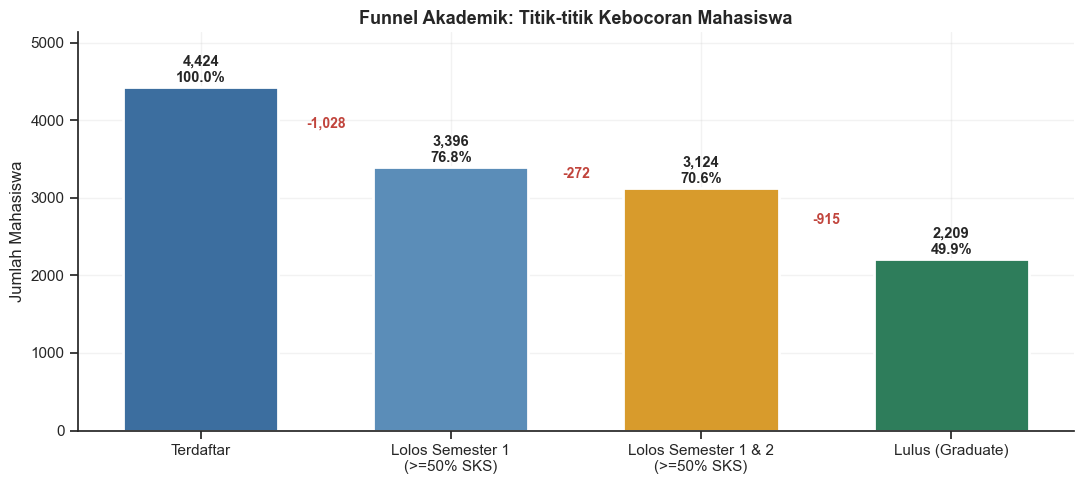

Kebocoran terbesar terjadi SETELAH lolos dua semester: 915 mahasiswa (20.7% dari total).


In [6]:
total    = len(df)
lulus_s1 = (df['rasio_sem1'] >= 0.5).sum()
lulus_s2 = ((df['rasio_sem1'] >= 0.5) & (df['rasio_sem2'] >= 0.5)).sum()
graduate = (df['Status'] == 'Graduate').sum()

tahap = ['Terdaftar', 'Lolos Semester 1\n(>=50% SKS)',
         'Lolos Semester 1 & 2\n(>=50% SKS)', 'Lulus (Graduate)']
nilai = [total, lulus_s1, lulus_s2, graduate]
warna = [COOL, '#5B8DB8', WARN, SAFE]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(tahap, nilai, color=warna, width=0.62, edgecolor='white', linewidth=2)
for i, (b, v) in enumerate(zip(bars, nilai)):
    ax.text(b.get_x() + b.get_width()/2, v + 70, f'{v:,}\n{v/total:.1%}',
            ha='center', fontweight='bold', fontsize=10.5)
    if i:
        hilang = nilai[i-1] - v
        ax.annotate(f'-{hilang:,}', xy=(i - 0.5, (nilai[i-1] + v)/2),
                    ha='center', fontsize=10, color=RISK, fontweight='bold')
ax.set_ylim(0, total * 1.16)
ax.set_ylabel('Jumlah Mahasiswa')
ax.set_title('Funnel Akademik: Titik-titik Kebocoran Mahasiswa', fontweight='bold', fontsize=13)
sns.despine(); plt.tight_layout(); plt.show()

print(f'Kebocoran terbesar terjadi SETELAH lolos dua semester: '
      f'{lulus_s2 - graduate:,} mahasiswa ({(lulus_s2-graduate)/total:.1%} dari total).')

> **Insight:** Funnel ini memperlihatkan sesuatu yang berlawanan dengan dugaan awal.
> Kebocoran pada tahap akademik awal relatif kecil — **23,2% gagal melewati semester 1**, lalu hanya
> **6,2% tambahan** yang gugur di semester 2. Kebocoran justru **paling besar terjadi setelah
> keduanya terlewati**: dari 3.124 mahasiswa yang lolos dua semester, hanya 2.209 yang akhirnya lulus.
>
> Artinya menyaring mahasiswa hanya berdasarkan "lolos atau tidak" di tiap semester **tidak cukup**.
> Diperlukan cara membaca yang lebih halus — yaitu melihat **arah pergerakan** performa, bukan sekadar
> posisinya. Itulah yang dianalisis pada bagian berikutnya.

### 3. Matriks Progresi — inti dari analisis ini

Setiap mahasiswa ditempatkan pada satu sel berdasarkan pasangan (performa semester 1, performa
semester 2). Nilai di dalam sel adalah **tingkat dropout kelompok tersebut**. Matriks ini menjawab
pertanyaan yang tidak bisa dijawab grafik satu dimensi: *apakah yang menentukan adalah posisi akhir,
atau perpindahan posisinya?*

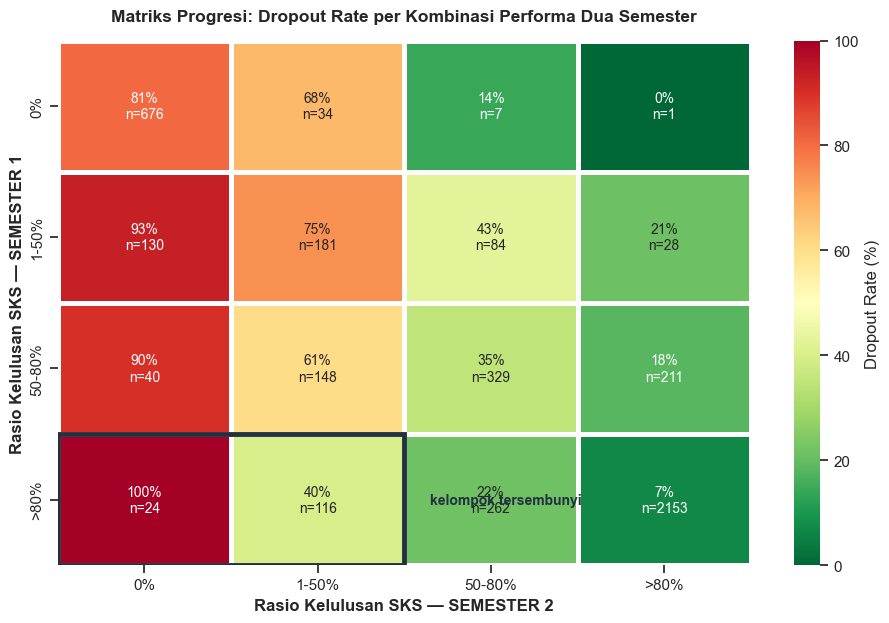

In [7]:
matriks = pd.crosstab(df['band_sem1'], df['band_sem2'],
                      values=(df['Status'] == 'Dropout') * 100, aggfunc='mean')
jumlah  = pd.crosstab(df['band_sem1'], df['band_sem2'])
anotasi = (matriks.round(0).astype('Int64').astype(str) + '%\n'
           + 'n=' + jumlah.astype(str))

fig, ax = plt.subplots(figsize=(9.5, 6.4))
sns.heatmap(matriks, annot=anotasi, fmt='', cmap='RdYlGn_r', vmin=0, vmax=100,
            linewidths=2.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Dropout Rate (%)'}, annot_kws={'fontsize': 10})
ax.set_xlabel('Rasio Kelulusan SKS — SEMESTER 2', fontweight='bold')
ax.set_ylabel('Rasio Kelulusan SKS — SEMESTER 1', fontweight='bold')
ax.set_title('Matriks Progresi: Dropout Rate per Kombinasi Performa Dua Semester',
             fontweight='bold', fontsize=12.5, pad=14)

# tandai sel "jatuh dari performa tinggi" yang menjadi temuan utama
ax.add_patch(plt.Rectangle((0, 3), 2, 1, fill=False, edgecolor=INK, lw=3.5))
ax.text(2.15, 3.5, 'kelompok tersembunyi', va='center', fontsize=10,
        fontweight='bold', color=INK)
plt.tight_layout(); plt.show()

In [8]:
kuat_s1 = df[df['rasio_sem1'] >= 0.5]
jatuh   = kuat_s1[kuat_s1['rasio_sem2'] < 0.5]
lemah_s1 = df[df['rasio_sem1'] < 0.5]
pulih    = lemah_s1[lemah_s1['rasio_sem2'] >= 0.5]

print('KELOMPOK YANG JATUH (kuat di semester 1, anjlok di semester 2)')
print(f'  {len(jatuh):,} dari {len(kuat_s1):,} mahasiswa ({len(jatuh)/len(kuat_s1):.1%})')
print(f'  Dropout rate mereka : {(jatuh["Status"]=="Dropout").mean():.1%}')
print(f'  Pembanding, yang tetap kuat di semester 2: '
      f'{(kuat_s1[kuat_s1["rasio_sem2"]>=0.5]["Status"]=="Dropout").mean():.1%}')
print()
print('KELOMPOK YANG PULIH (lemah di semester 1, bangkit di semester 2)')
print(f'  {len(pulih):,} dari {len(lemah_s1):,} mahasiswa ({len(pulih)/len(lemah_s1):.1%})')
print(f'  Dropout rate mereka : {(pulih["Status"]=="Dropout").mean():.1%}')
print(f'  Pembanding, yang tetap lemah di semester 2: '
      f'{(lemah_s1[lemah_s1["rasio_sem2"]<0.5]["Status"]=="Dropout").mean():.1%}')

KELOMPOK YANG JATUH (kuat di semester 1, anjlok di semester 2)
  272 dari 3,396 mahasiswa (8.0%)
  Dropout rate mereka : 68.8%
  Pembanding, yang tetap kuat di semester 2: 14.0%

KELOMPOK YANG PULIH (lemah di semester 1, bangkit di semester 2)
  86 dari 1,028 mahasiswa (8.4%)
  Dropout rate mereka : 34.9%
  Pembanding, yang tetap lemah di semester 2: 81.3%


> **Insight — dua temuan yang mengubah cara memantau:**
>
> **1. Ada kelompok berisiko yang tidak terlihat di semester 1.**
> Sebanyak **272 mahasiswa (8,0%)** melewati semester 1 dengan baik (lulus ≥50% SKS) lalu **anjlok di
> semester 2**. Dropout rate kelompok ini mencapai **68,8%** — hampir **lima kali lipat** mahasiswa
> yang tetap kuat di semester 2 (**14,0%**). Kalau institusi hanya memantau rapor semester 1, kelompok ini lolos dari
> pengawasan — mereka tampak baik-baik saja tepat sebelum jatuh.
>
> **2. Pemulihan itu nyata dan berdampak besar.**
> Sebanyak **86 mahasiswa** yang lemah di semester 1 berhasil bangkit di semester 2. Dropout rate
> mereka turun ke **34,9%**, dibanding **81,3%** pada mereka yang tetap lemah — kurang dari
> separuhnya. Ini bukti empiris bahwa
> **kondisi buruk di semester 1 bukan vonis** — dan karenanya intervensi memang layak dibiayai.
>
> Kesimpulan operasionalnya: institusi membutuhkan **dua titik pantau**, bukan satu. Pantauan
> semester 1 menangkap mereka yang jatuh sejak awal; pantauan semester 2 menangkap kelompok
> tersembunyi di atas. Inilah dasar rancangan model pada proyek ini.

### 4. Sebaran Rasio Kelulusan per Status

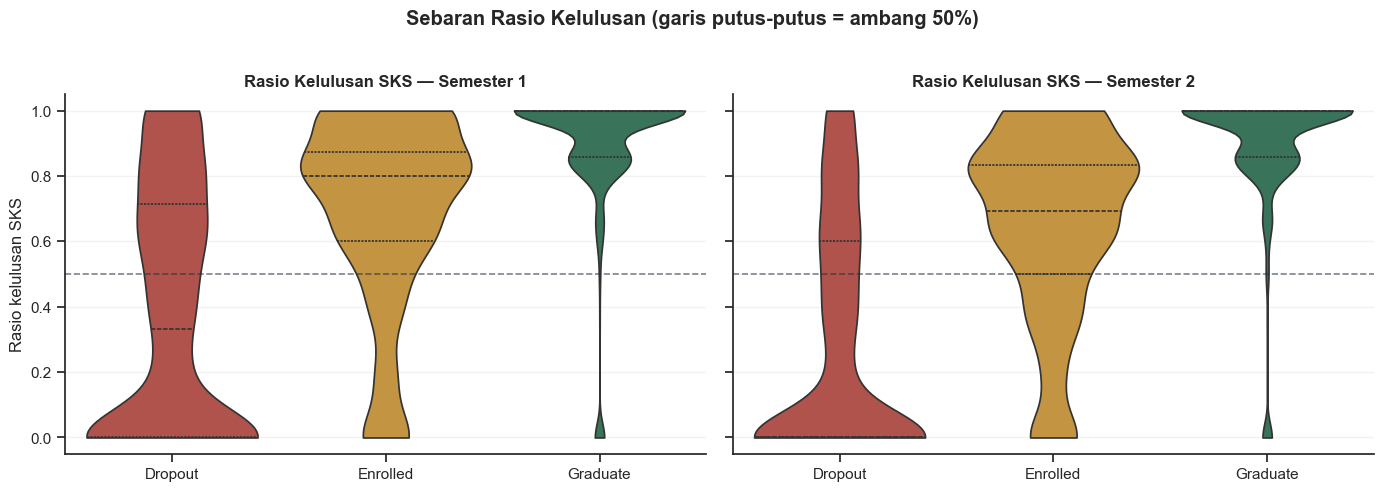

Proporsi mahasiswa dengan rasio kelulusan 0% (tidak lulus satu SKS pun):
  Dropout   semester 1:  40.1%   semester 2:  51.2%
  Enrolled  semester 1:   8.9%   semester 2:   8.6%
  Graduate  semester 1:   3.5%   semester 2:   3.4%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
urut = ['Dropout', 'Enrolled', 'Graduate']
for ax, kol, judul in zip(axes, ['rasio_sem1', 'rasio_sem2'],
                          ['Semester 1', 'Semester 2']):
    sns.violinplot(data=df, x='Status', y=kol, order=urut, ax=ax, cut=0,
                   palette=[STATUS_WARNA[s] for s in urut], inner='quartile')
    ax.set_title(f'Rasio Kelulusan SKS — {judul}', fontweight='bold')
    ax.set_ylabel('Rasio kelulusan SKS'); ax.set_xlabel('')
    ax.axhline(0.5, ls='--', color=INK, lw=1.2, alpha=0.6)
plt.suptitle('Sebaran Rasio Kelulusan (garis putus-putus = ambang 50%)',
             fontweight='bold', y=1.02)
sns.despine(); plt.tight_layout(); plt.show()

print('Proporsi mahasiswa dengan rasio kelulusan 0% (tidak lulus satu SKS pun):')
for s in urut:
    d = df[df.Status == s]
    print(f'  {s:<9} semester 1: {(d.rasio_sem1==0).mean():>6.1%}   '
          f'semester 2: {(d.rasio_sem2==0).mean():>6.1%}')

> **Insight:** Sebaran mahasiswa *dropout* menumpuk tebal di angka nol — **40,1% tidak meluluskan satu
> SKS pun di semester 1**, dan angkanya justru **naik menjadi 51,2% di semester 2**. Pola menebal ke
> arah nol ini tidak muncul pada mahasiswa *graduate*, yang distribusinya justru memadat di atas 80%.
> Mahasiswa *Enrolled* berada di antara keduanya — konsisten dengan statusnya sebagai kelompok yang
> hasil akhirnya belum ditentukan.

### 5. Beban SKS vs Tingkat Dropout per Program Studi

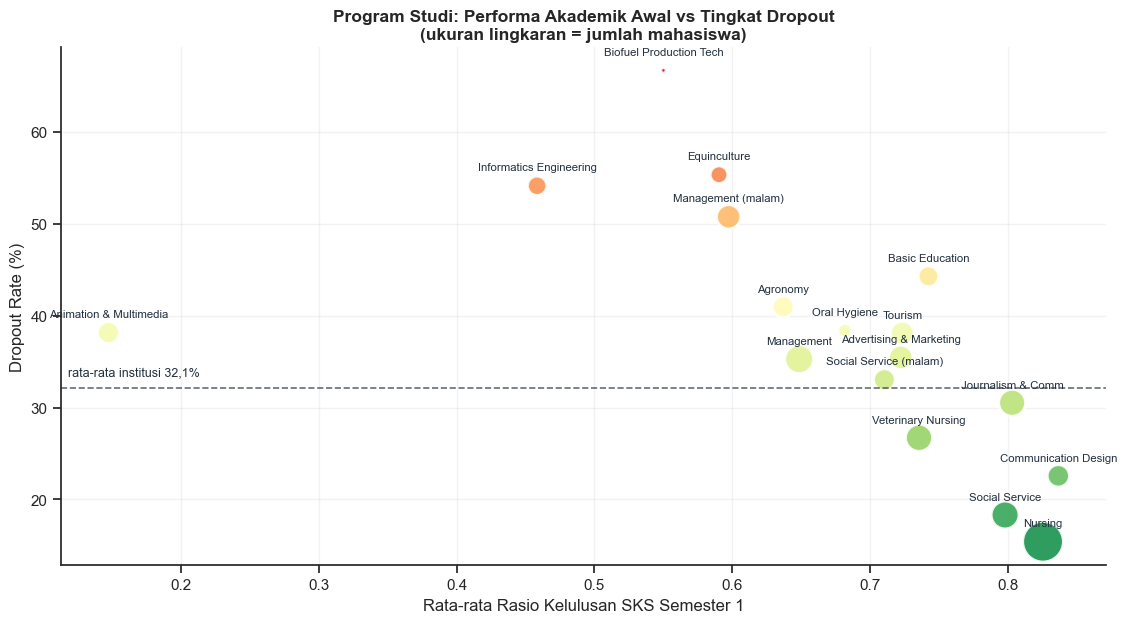

                   nama  sks_diambil  rasio_lulus  dropout  jumlah
Biofuel Production Tech        10.25         0.55    66.67      12
           Equinculture         5.71         0.59    55.32     141
Informatics Engineering         5.19         0.46    54.12     170
     Management (malam)         6.04         0.60    50.75     268
        Basic Education         6.77         0.74    44.27     192
               Agronomy         7.86         0.64    40.95     210
           Oral Hygiene         6.80         0.68    38.37      86
 Animation & Multimedia         2.18         0.15    38.14     215
                Tourism         6.15         0.72    38.10     252
Advertising & Marketing         5.82         0.72    35.45     268
             Management         5.59         0.65    35.26     380
 Social Service (malam)         7.24         0.71    33.02     215
      Journalism & Comm         5.96         0.80    30.51     331
     Veterinary Nursing         5.93         0.74    26.71    

In [10]:
prodi = (df.assign(nama=df['Course'].map(MAP_COURSE))
           .groupby('nama')
           .agg(sks_diambil=('Curricular_units_1st_sem_enrolled', 'mean'),
                rasio_lulus=('rasio_sem1', 'mean'),
                dropout=('Status', lambda s: (s == 'Dropout').mean() * 100),
                jumlah=('Status', 'size'))
           .reset_index())

fig, ax = plt.subplots(figsize=(11.5, 6.4))
sc = ax.scatter(prodi['rasio_lulus'], prodi['dropout'],
                s=prodi['jumlah'] * 1.1, c=prodi['dropout'],
                cmap='RdYlGn_r', vmin=10, vmax=70,
                edgecolor='white', linewidth=1.8, alpha=0.9)
for _, r in prodi.iterrows():
    ax.annotate(r['nama'], (r['rasio_lulus'], r['dropout']),
                textcoords='offset points', xytext=(0, 11),
                ha='center', fontsize=8.2, color=INK)
ax.axhline(32.1, ls='--', color=INK, lw=1.2, alpha=0.7)
ax.text(ax.get_xlim()[0] + 0.005, 33.4, 'rata-rata institusi 32,1%', fontsize=9, color=INK)
ax.set_xlabel('Rata-rata Rasio Kelulusan SKS Semester 1')
ax.set_ylabel('Dropout Rate (%)')
ax.set_title('Program Studi: Performa Akademik Awal vs Tingkat Dropout\n'
             '(ukuran lingkaran = jumlah mahasiswa)', fontweight='bold', fontsize=12.5)
sns.despine(); plt.tight_layout(); plt.show()

print(prodi.sort_values('dropout', ascending=False)
        .round(2).to_string(index=False))

> **Insight:** Terlihat hubungan negatif yang jelas (**Pearson r = −0,54**): program studi dengan
> rata-rata rasio kelulusan semester 1 rendah cenderung memiliki dropout rate tinggi. *Nursing* berada
> di pojok kanan bawah (rasio 0,83, dropout terendah **15,4%**), sementara *Equinculture* dan
> *Informatics Engineering* menempati pojok kiri atas.
>
> Terdapat satu pencilan penting yang tidak boleh diabaikan: ***Animation & Multimedia Design*** —
> rasio kelulusannya hanya **0,15**, jauh terendah, tetapi dropout rate-nya **38,1%** saja, sedikit di
> atas rata-rata. Penyebabnya terbaca pada kolom beban SKS: prodi ini hanya mengambil rata-rata
> **2,18 SKS** di semester 1, jauh di bawah prodi lain (5–10 SKS), sehingga rasio kelulusannya tidak
> setara maknanya. **Bila pencilan ini dikeluarkan, korelasinya menguat tajam menjadi r = −0,87.**
> Ini peringatan agar metrik pemantauan tidak diterapkan seragam lintas prodi tanpa memperhatikan
> struktur kurikulumnya.
>
> Karena rasio kelulusan semester 1 sudah diketahui **hanya beberapa bulan setelah mahasiswa masuk**,
> metrik ini bisa langsung dipakai sebagai indikator pemantauan tingkat program studi — tanpa
> menunggu satu angkatan selesai.

### 6. Faktor Finansial dalam Kaitannya dengan Performa Akademik

Faktor finansial dan akademik kerap dianalisis terpisah. Di sini keduanya disilangkan untuk melihat
apakah pengaruhnya saling menguatkan.

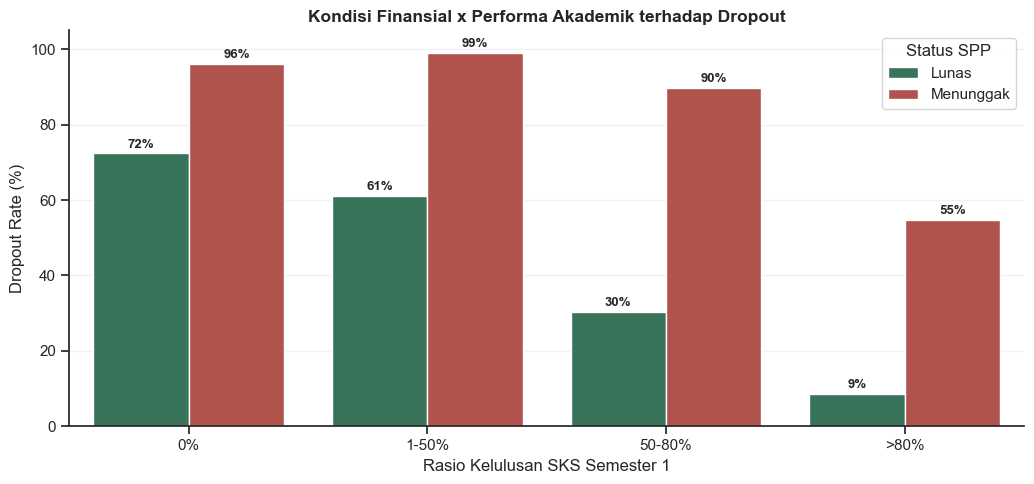

band_sem1       spp  dropout    n
       0%     Lunas     72.4  507
       0% Menunggak     96.2  211
    1-50%     Lunas     61.1  319
    1-50% Menunggak     99.0  104
   50-80%     Lunas     30.3  630
   50-80% Menunggak     89.8   98
     >80%     Lunas      8.6 2440
     >80% Menunggak     54.8  115


In [11]:
df['spp'] = df['Tuition_fees_up_to_date'].map(MAP_SPP)
silang = (df.groupby(['band_sem1', 'spp'])
            .agg(dropout=('Status', lambda s: (s == 'Dropout').mean() * 100),
                 n=('Status', 'size')).reset_index())
silang = silang[silang['n'] >= 15]

fig, ax = plt.subplots(figsize=(10.5, 5))
sns.barplot(data=silang, x='band_sem1', y='dropout', hue='spp', ax=ax,
            palette={'Lunas': SAFE, 'Menunggak': RISK}, edgecolor='white')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', fontsize=9.5, fontweight='bold', padding=2)
ax.set_xlabel('Rasio Kelulusan SKS Semester 1'); ax.set_ylabel('Dropout Rate (%)')
ax.set_title('Kondisi Finansial x Performa Akademik terhadap Dropout',
             fontweight='bold', fontsize=12.5)
ax.legend(title='Status SPP'); ax.set_ylim(0, 105)
sns.despine(); plt.tight_layout(); plt.show()

print(silang.round(1).to_string(index=False))

> **Insight — dua faktor ini saling menguatkan, bukan sekadar berjalan sendiri-sendiri.**
> Di dalam **setiap** kelompok performa akademik, mahasiswa yang menunggak SPP selalu memiliki dropout
> rate jauh lebih tinggi. Yang paling mencolok ada di kelompok berprestasi: mahasiswa dengan rasio
> kelulusan **di atas 80%** memiliki dropout rate hanya **8,6%** bila SPP-nya lunas, tetapi melonjak
> menjadi **54,8%** bila menunggak — **enam kali lipat**. Angka 54,8% itu bahkan lebih tinggi daripada
> mahasiswa berperforma sedang (50–80%) yang keuangannya lancar (**30,3%**).
>
> Implikasinya tegas: **prestasi akademik tidak melindungi mahasiswa dari masalah keuangan.**
> Institusi tidak bisa mengasumsikan mahasiswa berprestasi otomatis aman, dan intervensi finansial
> perlu berjalan terpisah dari intervensi akademik.

---

## Feature Engineering

Fitur mentah menggambarkan **posisi** mahasiswa. Yang menurut analisis di atas justru lebih
menentukan adalah **arah dan laju** perubahannya. Karena itu dibentuk fitur turunan berikut:

| Fitur | Rumus | Alasan |
|---|---|---|
| `rasio_sem1`, `rasio_sem2` | SKS lulus ÷ SKS diambil | Menyetarakan mahasiswa dengan beban SKS berbeda |
| `delta_rasio` | `rasio_sem2` − `rasio_sem1` | Menangkap **arah** pergerakan — dasar temuan "kelompok tersembunyi" |
| `delta_nilai` | nilai sem2 − nilai sem1 | Versi sinyal yang sama pada skala nilai |
| `total_lulus` | SKS lulus sem1 + sem2 | Akumulasi kemajuan menuju kelulusan |
| `tekanan_finansial` | (1 − SPP lunas) + debitur − beasiswa | Meringkas tiga sinyal keuangan menjadi satu skala −1…2 |
| `selisih_evaluasi` | jumlah evaluasi − SKS lulus | Banyak ujian tetapi sedikit lulus = indikasi kesulitan akademik |

Fitur `delta_*` hanya bisa dihitung setelah semester 2, sehingga **tidak tersedia** pada model
titik pantau semester 1 — konsisten dengan aturan ketersediaan data.

In [12]:
def buat_fitur(data, checkpoint):
    """Membentuk fitur turunan. checkpoint=1 hanya memakai data yang sudah ada
    di akhir semester 1; checkpoint=2 memakai data dua semester."""
    d = data.copy()
    a1 = d['Curricular_units_1st_sem_approved']
    e1 = d['Curricular_units_1st_sem_enrolled']

    d['rasio_sem1']        = rasio(a1, e1)
    d['tekanan_finansial'] = (1 - d['Tuition_fees_up_to_date']) + d['Debtor'] - d['Scholarship_holder']
    d['selisih_evaluasi']  = d['Curricular_units_1st_sem_evaluations'] - a1

    if checkpoint == 2:
        a2 = d['Curricular_units_2nd_sem_approved']
        e2 = d['Curricular_units_2nd_sem_enrolled']
        d['rasio_sem2']   = rasio(a2, e2)
        d['delta_rasio']  = d['rasio_sem2'] - d['rasio_sem1']
        d['delta_nilai']  = (d['Curricular_units_2nd_sem_grade']
                             - d['Curricular_units_1st_sem_grade'])
        d['total_lulus']  = a1 + a2
    return d


# Cek kekuatan sinyal fitur turunan yang paling penting
uji = buat_fitur(df[df.Status.isin(['Dropout', 'Graduate'])], checkpoint=2)
uji['is_dropout'] = (uji['Status'] == 'Dropout').astype(int)
korelasi = uji[['rasio_sem1', 'rasio_sem2', 'delta_rasio', 'delta_nilai',
                'total_lulus', 'tekanan_finansial', 'selisih_evaluasi',
                'is_dropout']].corr()['is_dropout'].drop('is_dropout')
print('Korelasi fitur turunan terhadap dropout:')
print(korelasi.sort_values(key=abs, ascending=False).round(3).to_string())

Korelasi fitur turunan terhadap dropout:
rasio_sem2          -0.740
rasio_sem1          -0.670
total_lulus         -0.617
tekanan_finansial    0.493
selisih_evaluasi     0.422
delta_rasio         -0.243
delta_nilai         -0.233


> **Insight:** Fitur turunan membawa sinyal yang kuat. `rasio_sem2` mencapai korelasi **−0,740** —
> lebih tinggi daripada kolom mentah manapun pada dataset asli — diikuti `rasio_sem1` (**−0,670**) dan
> `total_lulus` (**−0,617**). Ini membenarkan keputusan menormalkan SKS lulus terhadap SKS yang
> diambil.
>
> `tekanan_finansial` (**+0,493**) berhasil memadatkan tiga kolom keuangan menjadi satu fitur dengan
> korelasi yang bahkan melampaui kolom aslinya. Sebaliknya, `delta_rasio` (−0,243) dan `delta_nilai`
> (−0,233) berkorelasi lemah secara linear — wajar, karena sinyal "memburuk" bersifat **kondisional**
> (berbahaya hanya bila terjadi dari posisi tinggi) sehingga tidak tertangkap oleh korelasi lurus.
> Justru di sinilah model berbasis pohon berguna: ia mampu menangkap interaksi semacam ini yang luput
> dari ukuran korelasi.

---

## Data Preparation / Preprocessing

Tiga keputusan utama pada tahap ini:

**1. Membatasi data latih pada status final.** Mahasiswa berstatus `Enrolled` dikeluarkan dari
pelatihan karena hasil akhirnya belum diketahui — melabelinya berarti menebak. Kelompok ini justru
disimpan sebagai **populasi yang akan diprediksi**.

**2. Menyusun dua set fitur sesuai titik pantau.** Set semester 1 sengaja **tidak memuat satu pun**
kolom `2nd_sem`, agar model benar-benar bisa dipakai pada akhir semester 1 dan angkanya jujur
mencerminkan performa pada saat itu.

**3. Encoding tanpa One-Hot.** Fitur nominal (program studi, jalur masuk, pekerjaan orang tua)
diubah dengan `OrdinalEncoder`, lalu ditandai sebagai kategorikal bagi `HistGradientBoostingClassifier`
yang **menangani kategori secara native** — model memecah kategori berdasarkan kelompok, bukan
mengurutkannya. Pendekatan ini menghindari ledakan dimensi akibat One-Hot pada kolom berkardinalitas
tinggi, dan tidak memerlukan penskalaan karena model berbasis pohon.

In [13]:
# 1. Pemisahan populasi
df_aktif = df[df['Status'] == 'Enrolled'].copy()
df_latih = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
df_latih['target'] = (df_latih['Status'] == 'Dropout').astype(int)

print(f'Data pelatihan       : {len(df_latih):,} mahasiswa berstatus final')
print(f'Data mahasiswa aktif : {len(df_aktif):,} (populasi target prediksi)')
print(f'Proporsi dropout     : {df_latih["target"].mean():.1%}')

Data pelatihan       : 3,630 mahasiswa berstatus final
Data mahasiswa aktif : 794 (populasi target prediksi)
Proporsi dropout     : 39.1%


In [14]:
FITUR_NOMINAL = ['Marital_status', 'Application_mode', 'Course', 'Previous_qualification',
                 'Nacionality', 'Mothers_qualification', 'Fathers_qualification',
                 'Mothers_occupation', 'Fathers_occupation']

KOLOM_DIBUANG = ['Status', 'target', 'rasio_sem1', 'rasio_sem2', 'band_sem1', 'band_sem2', 'spp']

def siapkan_X(data, checkpoint):
    """Mengembalikan matriks fitur sesuai titik pantau."""
    mentah = data.drop(columns=[c for c in KOLOM_DIBUANG if c in data.columns])
    if checkpoint == 1:
        mentah = mentah.drop(columns=[c for c in mentah.columns if '2nd_sem' in c])
    return buat_fitur(mentah, checkpoint)

X1 = siapkan_X(df_latih, 1)
X2 = siapkan_X(df_latih, 2)
y  = df_latih['target']

assert not any('2nd_sem' in c for c in X1.columns), 'Kebocoran data pada set semester 1!'
print(f'Set fitur SEMESTER 1 : {X1.shape[1]} kolom')
print(f'Set fitur SEMESTER 2 : {X2.shape[1]} kolom')
print('Verifikasi: set semester 1 bebas dari kolom semester 2 -> OK')

Set fitur SEMESTER 1 : 33 kolom
Set fitur SEMESTER 2 : 43 kolom
Verifikasi: set semester 1 bebas dari kolom semester 2 -> OK


In [15]:
# 2. Pembagian data (indeks dijaga identik agar kedua checkpoint bisa dibandingkan adil)
idx_train, idx_test = train_test_split(
    df_latih.index, test_size=0.2, random_state=SEED, stratify=y)

DATA = {}
for cp, X in [(1, X1), (2, X2)]:
    DATA[cp] = {
        'X_train': X.loc[idx_train], 'X_test': X.loc[idx_test],
        'y_train': y.loc[idx_train], 'y_test': y.loc[idx_test],
        'kolom': list(X.columns)
    }
print(f'Train: {len(idx_train):,} | Test: {len(idx_test):,}')
print('Kedua model memakai pembagian baris yang persis sama, sehingga selisih')
print('performanya murni berasal dari perbedaan informasi yang tersedia.')

Train: 2,904 | Test: 726
Kedua model memakai pembagian baris yang persis sama, sehingga selisih
performanya murni berasal dari perbedaan informasi yang tersedia.


In [16]:
# 3. Pipeline: OrdinalEncoder + HistGradientBoosting dengan kategori native
def buat_pipeline(kolom, **params):
    pre = ColumnTransformer(
        [('nominal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
          FITUR_NOMINAL)],
        remainder='passthrough', verbose_feature_names_out=False)
    # setelah ColumnTransformer, kolom nominal berada di posisi paling depan
    mask_kategori = [True] * len(FITUR_NOMINAL) + [False] * (len(kolom) - len(FITUR_NOMINAL))
    return Pipeline([
        ('pra', pre),
        ('model', HistGradientBoostingClassifier(
            categorical_features=mask_kategori, class_weight='balanced',
            random_state=SEED, **params))
    ])

contoh = buat_pipeline(DATA[2]['kolom'])
print(f'{len(FITUR_NOMINAL)} fitur ditandai kategorikal, '
      f'{len(DATA[2]["kolom"]) - len(FITUR_NOMINAL)} fitur numerik dilewatkan apa adanya.')
print('Tidak ada One-Hot Encoding dan tidak ada penskalaan -> dimensi tetap',
      len(DATA[2]['kolom']), 'kolom.')

9 fitur ditandai kategorikal, 34 fitur numerik dilewatkan apa adanya.
Tidak ada One-Hot Encoding dan tidak ada penskalaan -> dimensi tetap 43 kolom.


---

## Modeling

Tiga algoritma berbasis pohon dibandingkan, dipilih karena cocok untuk data tabel campuran
kategorikal–numerik dan tidak memerlukan penskalaan:

| Model | Karakter | Alasan dipilih |
|---|---|---|
| **Decision Tree** | Pohon tunggal, sepenuhnya dapat dibaca | *Baseline* yang wajib dilampaui model ensemble |
| **Extra Trees** | Ensemble acak, varians rendah | Pembanding pendekatan *bagging* |
| **HistGradient Boosting** | *Boosting* berbasis histogram, kategori native | Cepat dan biasanya paling akurat pada data tabular |

Evaluasi memakai **5-fold Stratified Cross Validation** dengan metrik **ROC-AUC**, dijalankan
terpisah untuk kedua titik pantau.

In [17]:
kandidat = {
    'Decision Tree':      DecisionTreeClassifier(max_depth=6, class_weight='balanced',
                                                 random_state=SEED),
    'Extra Trees':        ExtraTreesClassifier(n_estimators=400, class_weight='balanced',
                                               random_state=SEED, n_jobs=-1),
    'HistGradient Boost': None   # diisi oleh pipeline khusus
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
hasil = []

for cp in (1, 2):
    d = DATA[cp]
    for nama in kandidat:
        if nama == 'HistGradient Boost':
            est = buat_pipeline(d['kolom'])
        else:
            est = Pipeline([('pra', ColumnTransformer(
                [('nominal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
                  FITUR_NOMINAL)], remainder='passthrough',
                verbose_feature_names_out=False)), ('model', kandidat[nama])])
        skor = cross_val_score(est, d['X_train'], d['y_train'], cv=cv,
                               scoring='roc_auc', n_jobs=-1)
        est.fit(d['X_train'], d['y_train'])
        prob = est.predict_proba(d['X_test'])[:, 1]
        hasil.append({'Checkpoint': f'Semester {cp}', 'Model': nama,
                      'CV ROC-AUC': skor.mean(), 'CV Std': skor.std(),
                      'Test ROC-AUC': roc_auc_score(d['y_test'], prob),
                      'Test PR-AUC': average_precision_score(d['y_test'], prob)})

perbandingan = pd.DataFrame(hasil).set_index(['Checkpoint', 'Model']).round(4)
perbandingan

CV ROC-AUC  CV Std  Test ROC-AUC  Test PR-AUC
Checkpoint Model                                                            
Semester 1 Decision Tree           0.8794  0.0149        0.8819       0.8407
           Extra Trees             0.9379  0.0108        0.9342       0.9297
           HistGradient Boost      0.9388  0.0096        0.9305       0.9267
Semester 2 Decision Tree           0.9112  0.0160        0.9193       0.8906
           Extra Trees             0.9578  0.0074        0.9459       0.9457
           HistGradient Boost      0.9515  0.0084        0.9498       0.9483

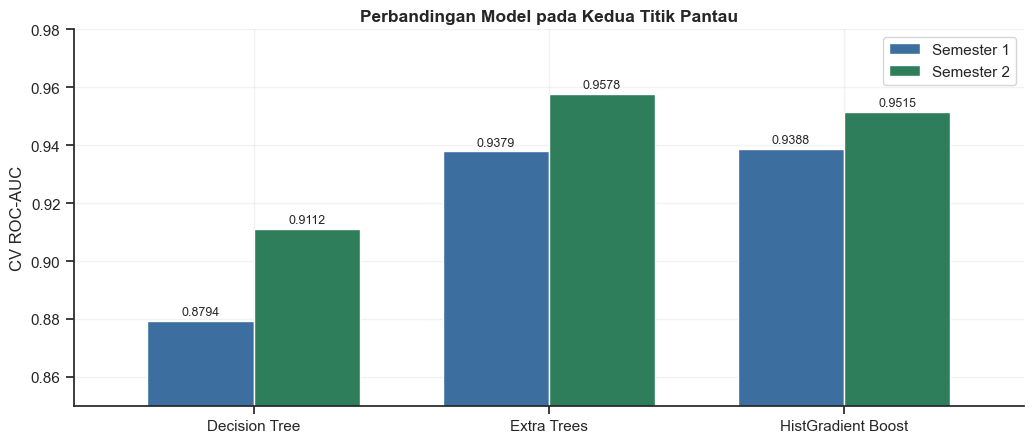

Semester 1: model terbaik = HistGradient Boost (0.9388)
Semester 2: model terbaik = Extra Trees (0.9578)


In [18]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
plot = perbandingan['CV ROC-AUC'].unstack(0)
plot.plot(kind='bar', ax=ax, color=[COOL, SAFE], width=0.72, edgecolor='white')
for c in ax.containers:
    ax.bar_label(c, fmt='%.4f', fontsize=9, padding=2)
ax.set_ylim(0.85, 0.98); ax.set_ylabel('CV ROC-AUC'); ax.set_xlabel('')
ax.set_title('Perbandingan Model pada Kedua Titik Pantau', fontweight='bold', fontsize=12.5)
ax.legend(title=''); plt.xticks(rotation=0)
sns.despine(); plt.tight_layout(); plt.show()

for cp in (1, 2):
    sub = perbandingan.loc[f'Semester {cp}']
    print(f'Semester {cp}: model terbaik = {sub["CV ROC-AUC"].idxmax()} '
          f'({sub["CV ROC-AUC"].max():.4f})')

> **Insight:** *Decision Tree* tunggal tertinggal jelas pada kedua titik pantau (0,879 dan 0,911),
> membuktikan pendekatan *ensemble* memang diperlukan. Namun **Extra Trees dan HistGradient Boosting
> praktis seri**:
>
> | | Extra Trees | HistGradient Boosting |
> |---|---|---|
> | CV ROC-AUC Sem 1 | 0,9379 | **0,9388** |
> | CV ROC-AUC Sem 2 | **0,9578** | 0,9515 |
> | Test ROC-AUC Sem 2 | 0,9459 | **0,9498** |
> | Test PR-AUC Sem 2 | 0,9457 | **0,9483** |
>
> Keduanya saling bergantian unggul, dan selisihnya (0,001–0,006) **lebih kecil daripada standar
> deviasi antar-*fold*** (0,007–0,011). Yang paling menentukan: pada semester 2, Extra Trees unggul di
> *cross validation* tetapi **kalah di data uji** pada kedua metrik — pertanda keunggulannya tidak
> stabil.
>
> **HistGradient Boosting dipilih** karena dua alasan operasional: ia menangani fitur kategorikal
> secara native (tanpa One-Hot, sehingga dimensi tetap ringkas), dan memakai algoritma yang sama untuk
> kedua titik pantau membuat skor keduanya **langsung dapat dibandingkan** — syarat penting bagi
> sistem dua checkpoint ini.
>
> Untuk keputusan bisnis, angka yang paling penting adalah **selisih antar titik pantau: hanya sekitar
> 0,015–0,019 ROC-AUC**. Menunggu satu semester tambahan memang menaikkan akurasi, tetapi
> peningkatannya kecil dibanding waktu bertindak yang hilang. Inilah jawaban atas permasalahan bisnis
> nomor 2.
>
> Yang paling penting untuk keputusan bisnis: **selisih antara kedua titik pantau hanya sekitar
> 0,015–0,02 ROC-AUC**. Menunggu satu semester tambahan memang meningkatkan akurasi, tetapi
> peningkatannya kecil — sementara waktu yang hilang untuk bertindak sangat berharga. Angka inilah
> yang menjawab permasalahan bisnis nomor 2.

### Hyperparameter Tuning

`RandomizedSearchCV` dipilih daripada pencarian grid karena ruang parameter `HistGradientBoosting`
cukup luas (5 dimensi, sebagian kontinu). Pencarian acak menjelajah ruang tersebut jauh lebih efisien
— 40 kombinasi acak umumnya menemukan wilayah optimal yang setara dengan ratusan kombinasi grid.

In [19]:
RUANG_PARAM = {
    'model__max_iter':          randint(150, 500),
    'model__learning_rate':     uniform(0.03, 0.17),
    'model__max_leaf_nodes':    randint(8, 48),
    'model__min_samples_leaf':  randint(10, 60),
    'model__l2_regularization': uniform(0.0, 2.0),
}

MODEL_FINAL = {}
for cp in (1, 2):
    d = DATA[cp]
    pencarian = RandomizedSearchCV(
        buat_pipeline(d['kolom']), RUANG_PARAM, n_iter=40, cv=cv,
        scoring='roc_auc', random_state=SEED, n_jobs=-1)
    pencarian.fit(d['X_train'], d['y_train'])
    MODEL_FINAL[cp] = pencarian.best_estimator_

    print(f'--- Titik pantau SEMESTER {cp} ---')
    for k, v in pencarian.best_params_.items():
        print(f'   {k.replace("model__", ""):<20}: '
              f'{round(v, 4) if isinstance(v, float) else v}')
    print(f'   CV ROC-AUC terbaik  : {pencarian.best_score_:.4f}\n')

--- Titik pantau SEMESTER 1 ---
   l2_regularization   : 0.9112
   learning_rate       : 0.0824
   max_iter            : 173
   max_leaf_nodes      : 16
   min_samples_leaf    : 35
   CV ROC-AUC terbaik  : 0.9404



--- Titik pantau SEMESTER 2 ---
   l2_regularization   : 1.1702
   learning_rate       : 0.058
   max_iter            : 177
   max_leaf_nodes      : 36
   min_samples_leaf    : 18
   CV ROC-AUC terbaik  : 0.9558



---

## Evaluation

### Menentukan ambang batas melalui analisis biaya

Ambang batas 0,50 hanya optimal bila kedua jenis kesalahan berbiaya sama — dan di sini jelas tidak.
Alih-alih memilihnya berdasarkan tampilan grafik, ambang batas dihitung dari **ekspektasi biaya**:

| Keadaan | Biaya bagi institusi |
|---|---|
| Dropout tidak terdeteksi (**FN**) | `R` — kehilangan seluruh sisa pendapatan mahasiswa |
| Dropout terdeteksi (**TP**) | `B` + (1 − `p`) × `R` — biaya intervensi, dan tetap rugi bila intervensi gagal |
| Salah tandai mahasiswa aman (**FP**) | `B` — biaya intervensi yang sebenarnya tidak perlu |
| Aman & tidak ditandai (**TN**) | 0 |

Secara aljabar, menandai seorang mahasiswa layak dilakukan bila probabilitas dropout-nya melampaui
**`B / (p × R)`**. Nilai `R`, `B`, dan `p` di bawah ini adalah **asumsi ilustratif** yang harus
diganti dengan angka riil institusi — bagian setelah ini menguji seberapa besar pengaruh asumsi
tersebut terhadap keputusan akhir.

In [20]:
RUGI_DROPOUT   = 30_000_000   # R : sisa pendapatan yang hilang per mahasiswa (asumsi)
BIAYA_INTERVENSI = 1_500_000  # B : konseling, tutoring, administrasi (asumsi)
PELUANG_BERHASIL = 0.40       # p : peluang intervensi menyelamatkan mahasiswa (asumsi)

def biaya_total(y_true, prob, ambang):
    pred = (prob >= ambang).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    return (fn * RUGI_DROPOUT
            + tp * (BIAYA_INTERVENSI + (1 - PELUANG_BERHASIL) * RUGI_DROPOUT)
            + fp * BIAYA_INTERVENSI)

ambang_teoretis = BIAYA_INTERVENSI / (PELUANG_BERHASIL * RUGI_DROPOUT)
print(f'Ambang batas teoretis = B / (p x R) = {ambang_teoretis:.3f}')

PROB, AMBANG = {}, {}
for cp in (1, 2):
    d = DATA[cp]
    PROB[cp] = MODEL_FINAL[cp].predict_proba(d['X_test'])[:, 1]
    kandidat_th = np.arange(0.05, 0.80, 0.025)
    biaya = [biaya_total(d['y_test'].values, PROB[cp], t) for t in kandidat_th]
    AMBANG[cp] = round(float(kandidat_th[int(np.argmin(biaya))]), 3)
    tanpa_model = int(d['y_test'].sum()) * RUGI_DROPOUT
    print(f'Semester {cp}: ambang optimal empiris = {AMBANG[cp]} | '
          f'biaya Rp{min(biaya):,.0f} vs tanpa model Rp{tanpa_model:,.0f} '
          f'(hemat {100*(1-min(biaya)/tanpa_model):.1f}%)')

Ambang batas teoretis = B / (p x R) = 0.125
Semester 1: ambang optimal empiris = 0.1 | biaya Rp5,941,500,000 vs tanpa model Rp8,520,000,000 (hemat 30.3%)
Semester 2: ambang optimal empiris = 0.15 | biaya Rp5,865,000,000 vs tanpa model Rp8,520,000,000 (hemat 31.2%)


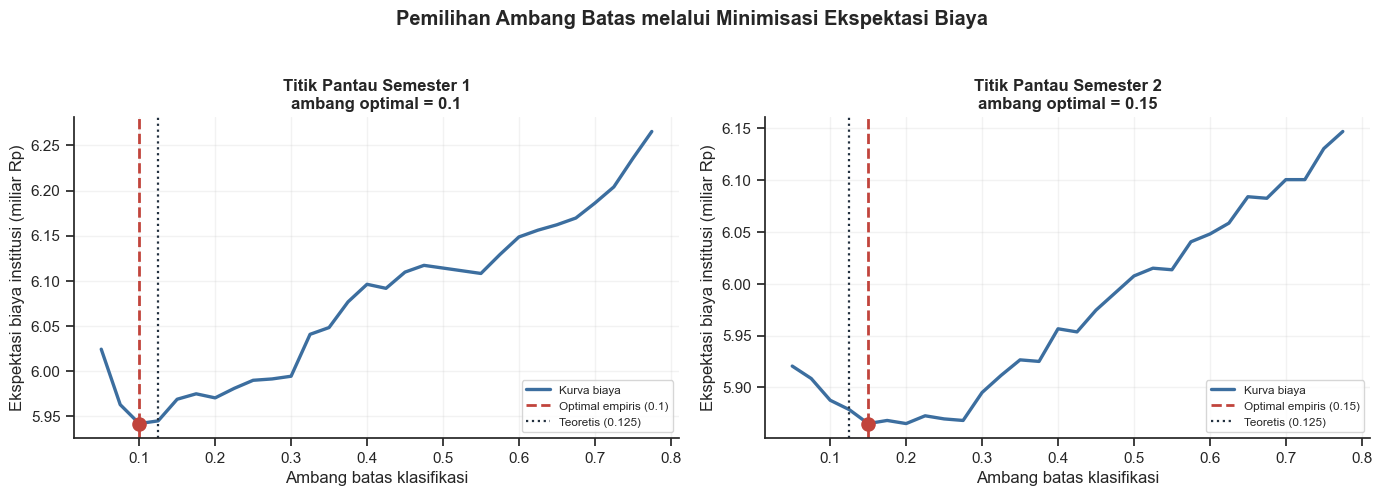

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
kandidat_th = np.arange(0.05, 0.80, 0.025)
for ax, cp in zip(axes, (1, 2)):
    d = DATA[cp]
    biaya = np.array([biaya_total(d['y_test'].values, PROB[cp], t)
                      for t in kandidat_th]) / 1e9
    ax.plot(kandidat_th, biaya, color=COOL, lw=2.4)
    ax.axvline(AMBANG[cp], ls='--', color=RISK, lw=2)
    ax.axvline(ambang_teoretis, ls=':', color=INK, lw=1.6)
    ax.scatter([AMBANG[cp]], [biaya.min()], color=RISK, s=90, zorder=5)
    ax.set_title(f'Titik Pantau Semester {cp}\nambang optimal = {AMBANG[cp]}',
                 fontweight='bold')
    ax.set_xlabel('Ambang batas klasifikasi')
    ax.set_ylabel('Ekspektasi biaya institusi (miliar Rp)')
    ax.legend(['Kurva biaya', f'Optimal empiris ({AMBANG[cp]})',
               f'Teoretis ({ambang_teoretis:.3f})'], fontsize=8.5)
plt.suptitle('Pemilihan Ambang Batas melalui Minimisasi Ekspektasi Biaya',
             fontweight='bold', y=1.03)
sns.despine(); plt.tight_layout(); plt.show()

> **Insight:** Ambang optimal hasil perhitungan empiris (**0,10** untuk semester 1 dan **0,15** untuk
> semester 2) berada sangat dekat dengan nilai teoretis **0,125** — kedua pendekatan saling
> mengonfirmasi. Keduanya jauh di bawah 0,50, dan itu memang seharusnya: ketika satu *dropout* yang
> terlewat merugikan **20 kali lipat** biaya satu sesi konseling, menandai lebih banyak mahasiswa
> adalah keputusan yang rasional secara ekonomi.
>
> Dibandingkan kondisi tanpa model, pendekatan ini menekan ekspektasi kerugian sekitar **30%**.

### Uji sensitivitas terhadap asumsi biaya

Ketiga angka biaya di atas adalah asumsi. Bagian ini menguji: seandainya asumsinya meleset jauh,
apakah keputusan ambang batasnya berubah drastis?

In [22]:
skenario = [
    ('Konservatif  (R=15jt, p=25%)', 15_000_000, 1_500_000, 0.25),
    ('Dasar        (R=30jt, p=40%)', 30_000_000, 1_500_000, 0.40),
    ('Optimistis   (R=45jt, p=60%)', 45_000_000, 1_500_000, 0.60),
    ('Intervensi mahal (B=4jt)    ', 30_000_000, 4_000_000, 0.40),
]
baris = []
for nama, R, B, p in skenario:
    simpan = (RUGI_DROPOUT, BIAYA_INTERVENSI, PELUANG_BERHASIL)
    RUGI_DROPOUT, BIAYA_INTERVENSI, PELUANG_BERHASIL = R, B, p
    r = {'Skenario': nama, 'Teoretis': round(B / (p * R), 3)}
    for cp in (1, 2):
        b = [biaya_total(DATA[cp]['y_test'].values, PROB[cp], t) for t in kandidat_th]
        r[f'Ambang Sem {cp}'] = round(float(kandidat_th[int(np.argmin(b))]), 3)
    baris.append(r)
    RUGI_DROPOUT, BIAYA_INTERVENSI, PELUANG_BERHASIL = simpan

sensitivitas = pd.DataFrame(baris).set_index('Skenario')
print(sensitivitas.to_string())
print()
print('Rentang ambang batas Semester 2 di seluruh skenario: '
      f'{sensitivitas["Ambang Sem 2"].min()} - {sensitivitas["Ambang Sem 2"].max()}')

                              Teoretis  Ambang Sem 1  Ambang Sem 2
Skenario                                                          
Konservatif  (R=15jt, p=25%)     0.400         0.550         0.375
Dasar        (R=30jt, p=40%)     0.125         0.100         0.150
Optimistis   (R=45jt, p=60%)     0.056         0.075         0.150
Intervensi mahal (B=4jt)         0.333         0.300         0.275

Rentang ambang batas Semester 2 di seluruh skenario: 0.15 - 0.375


> **Insight — hasilnya berbeda untuk kedua titik pantau, dan perbedaan itu penting:**
>
> **Titik pantau semester 2 kokoh.** Di seluruh skenario, ambang optimalnya bertahan pada rentang
> **0,15–0,375** dan tidak pernah mendekati 0,50. Keputusan untuk bersikap agresif di semester 2
> karenanya **tidak bergantung pada asumsi biaya yang kebetulan dipilih**.
>
> **Titik pantau semester 1 jauh lebih peka.** Ambangnya bergerak dari **0,075** (skenario optimistis)
> hingga **0,550** (skenario konservatif) — rentang yang sangat lebar. Penyebabnya masuk akal: karena
> *precision* model semester 1 lebih rendah, setiap alarm palsu berbiaya relatif lebih besar, sehingga
> keputusannya sangat sensitif terhadap besarnya `B` dan `p`.
>
> Konsekuensi praktisnya bukan membatalkan pemantauan semester 1, melainkan **menetapkan urutan
> prioritas penerapan**: mulai dari titik pantau semester 2 yang keputusannya kokoh, sambil mengukur
> biaya intervensi dan peluang keberhasilan yang sebenarnya. Setelah angka riil diperoleh, ambang
> semester 1 dapat ditetapkan dengan percaya diri. Justru di sinilah nilai analisis sensitivitas:
> ia menunjukkan **asumsi mana yang wajib diverifikasi lebih dulu**, bukan sekadar membenarkan
> pilihan yang sudah dibuat.

### Performa akhir kedua model

In [23]:
ringkas = []
for cp in (1, 2):
    yt = DATA[cp]['y_test']
    pred = (PROB[cp] >= AMBANG[cp]).astype(int)
    ringkas.append({
        'Titik Pantau': f'Semester {cp}', 'Ambang': AMBANG[cp],
        'Accuracy': accuracy_score(yt, pred), 'Precision': precision_score(yt, pred),
        'Recall': recall_score(yt, pred), 'F1': f1_score(yt, pred),
        'ROC-AUC': roc_auc_score(yt, PROB[cp]),
        'PR-AUC': average_precision_score(yt, PROB[cp])})
metrik = pd.DataFrame(ringkas).set_index('Titik Pantau').round(4)
print(metrik.to_string())

for cp in (1, 2):
    print(f'\n=== Semester {cp} (ambang {AMBANG[cp]}) ===')
    print(classification_report(DATA[cp]['y_test'],
                                (PROB[cp] >= AMBANG[cp]).astype(int),
                                target_names=['Aman', 'Berisiko Dropout'], digits=4))

              Ambang  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Titik Pantau                                                              
Semester 1      0.10    0.8030     0.6831  0.9261  0.7862   0.9285  0.9268
Semester 2      0.15    0.8815     0.8037  0.9225  0.8590   0.9522  0.9500

=== Semester 1 (ambang 0.1) ===
                  precision    recall  f1-score   support

            Aman     0.9384    0.7240    0.8174       442
Berisiko Dropout     0.6831    0.9261    0.7862       284

        accuracy                         0.8030       726
       macro avg     0.8108    0.8250    0.8018       726
    weighted avg     0.8385    0.8030    0.8052       726


=== Semester 2 (ambang 0.15) ===
                  precision    recall  f1-score   support

            Aman     0.9450    0.8552    0.8979       442
Berisiko Dropout     0.8037    0.9225    0.8590       284

        accuracy                         0.8815       726
       macro avg     0.8743    0.8889    0.8784 

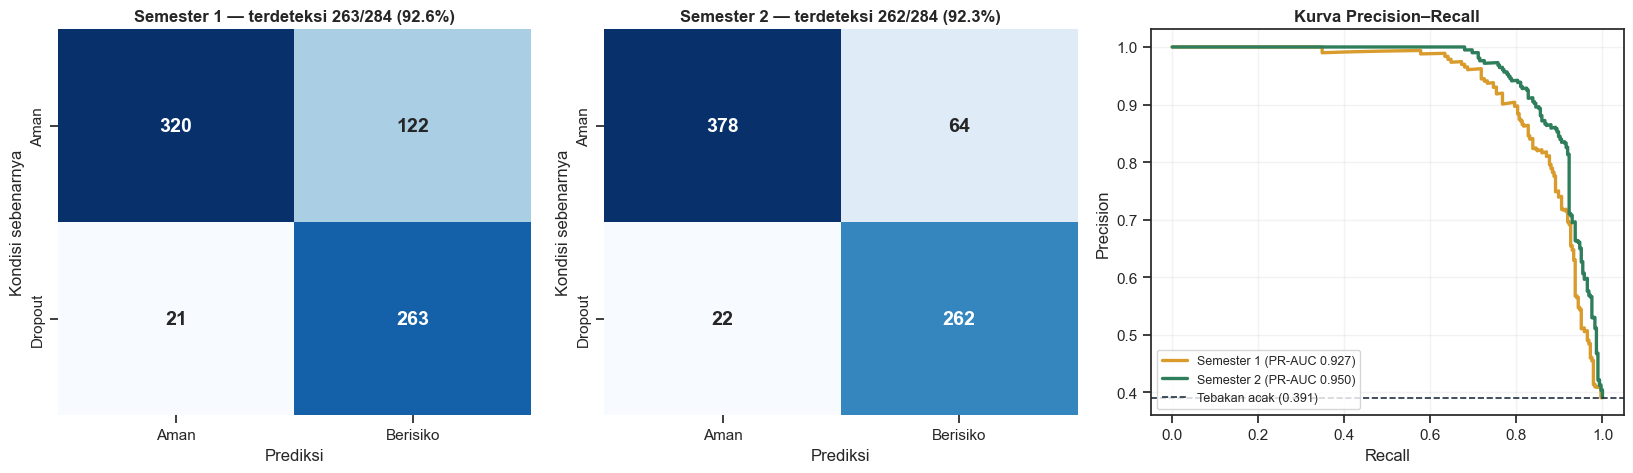

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))

# Confusion matrix kedua checkpoint
for ax, cp in zip(axes[:2], (1, 2)):
    cm = confusion_matrix(DATA[cp]['y_test'], (PROB[cp] >= AMBANG[cp]).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                annot_kws={'size': 14, 'weight': 'bold'},
                xticklabels=['Aman', 'Berisiko'], yticklabels=['Aman', 'Dropout'])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'Semester {cp} — terdeteksi {tp}/{tp+fn} '
                 f'({tp/(tp+fn):.1%})', fontweight='bold')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Kondisi sebenarnya')

# Kurva Precision-Recall (lebih informatif dari ROC untuk kelas minoritas)
for cp, warna in [(1, WARN), (2, SAFE)]:
    pr, rc, _ = precision_recall_curve(DATA[cp]['y_test'], PROB[cp])
    axes[2].plot(rc, pr, color=warna, lw=2.4,
                 label=f'Semester {cp} (PR-AUC {average_precision_score(DATA[cp]["y_test"], PROB[cp]):.3f})')
axes[2].axhline(DATA[2]['y_test'].mean(), ls='--', color=INK, lw=1.2,
                label=f'Tebakan acak ({DATA[2]["y_test"].mean():.3f})')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Kurva Precision–Recall', fontweight='bold')
axes[2].legend(fontsize=9, loc='lower left')
plt.tight_layout(); plt.show()

> **Insight — membaca angka ini dengan benar:**
>
> Pada ambang optimalnya, **model semester 1 menangkap 92,6% mahasiswa yang akan dropout** dan model
> semester 2 menangkap **92,2%**. Kemampuan mendeteksi keduanya praktis setara — inilah pembenaran
> utama untuk mulai bertindak sejak semester 1.
>
> Perbedaannya ada pada **precision**: 68,3% di semester 1 versus 80,4% di semester 2. Artinya
> peringatan di semester 1 memang lebih banyak mengandung alarm palsu. Namun ini **bukan kelemahan
> yang tersembunyi, melainkan konsekuensi yang sudah diperhitungkan**: analisis biaya secara sadar
> memilih titik ini karena satu *dropout* yang terlewat jauh lebih mahal daripada satu sesi konseling
> yang tidak perlu.
>
> Cara memanfaatkannya di lapangan: **semester 1 untuk penyaringan luas** (kontak ringan, undangan
> tutoring), **semester 2 untuk penanganan intensif** (konseling wajib, restrukturisasi SPP) karena
> daftarnya jauh lebih akurat.

### Fitur paling berpengaruh

*Permutation importance* dihitung pada data uji — mengukur penurunan performa ketika nilai suatu
fitur diacak. Metode ini dinilai pada data yang belum pernah dilihat model, sehingga tidak bias
terhadap fitur berkardinalitas tinggi seperti *importance* bawaan berbasis impurity.

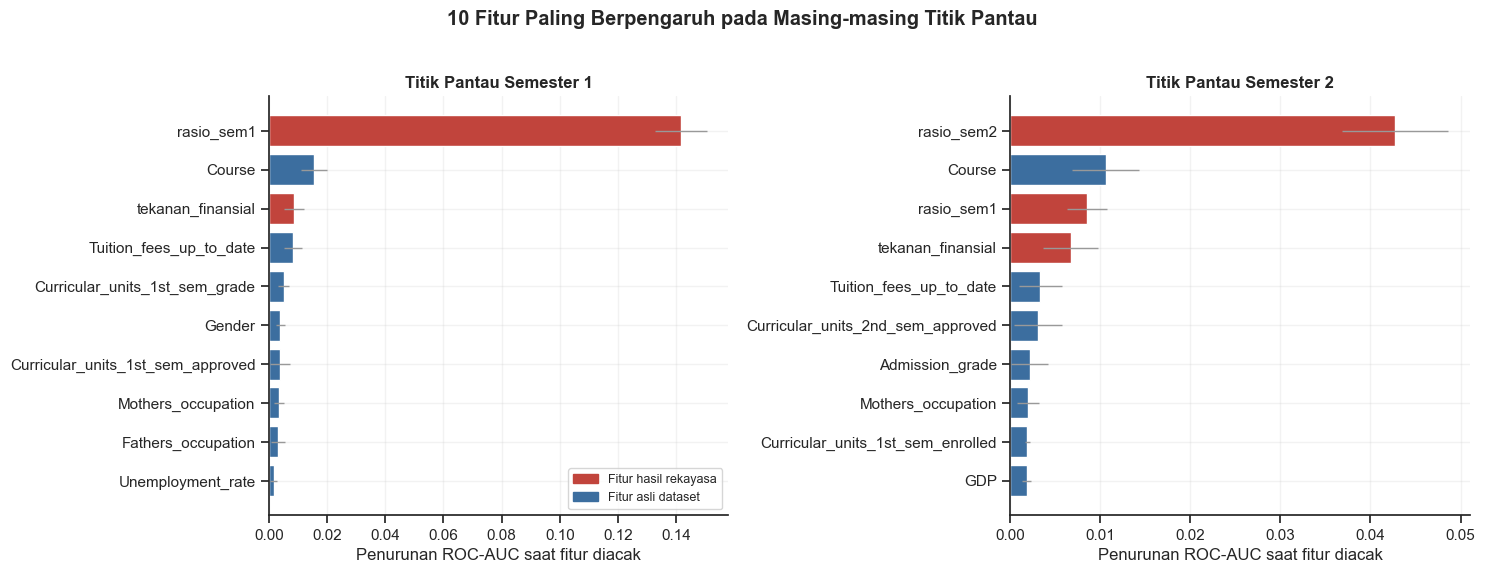

Semester 1: 2 dari 10 fitur teratas adalah hasil rekayasa -> ['rasio_sem1', 'tekanan_finansial']
Semester 2: 3 dari 10 fitur teratas adalah hasil rekayasa -> ['rasio_sem2', 'rasio_sem1', 'tekanan_finansial']


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
PENTING = {}
for ax, cp in zip(axes, (1, 2)):
    d = DATA[cp]
    perm = permutation_importance(MODEL_FINAL[cp], d['X_test'], d['y_test'],
                                  n_repeats=12, random_state=SEED,
                                  scoring='roc_auc', n_jobs=-1)
    imp = (pd.DataFrame({'fitur': d['kolom'], 'nilai': perm.importances_mean,
                         'std': perm.importances_std})
             .sort_values('nilai', ascending=False).head(10))
    PENTING[cp] = imp['fitur'].tolist()
    warna = [RISK if f in ('rasio_sem1', 'rasio_sem2', 'delta_rasio', 'total_lulus',
                           'tekanan_finansial', 'delta_nilai', 'selisih_evaluasi')
             else COOL for f in imp['fitur']]
    ax.barh(imp['fitur'], imp['nilai'], xerr=imp['std'], color=warna,
            edgecolor='white', error_kw={'ecolor': '#999', 'lw': 1})
    ax.invert_yaxis()
    ax.set_title(f'Titik Pantau Semester {cp}', fontweight='bold')
    ax.set_xlabel('Penurunan ROC-AUC saat fitur diacak')

axes[0].legend(handles=[mpatches.Patch(color=RISK, label='Fitur hasil rekayasa'),
                        mpatches.Patch(color=COOL, label='Fitur asli dataset')],
               fontsize=9, loc='lower right')
plt.suptitle('10 Fitur Paling Berpengaruh pada Masing-masing Titik Pantau',
             fontweight='bold', y=1.02)
sns.despine(); plt.tight_layout(); plt.show()

for cp in (1, 2):
    buatan = [f for f in PENTING[cp] if f in ('rasio_sem1', 'rasio_sem2', 'delta_rasio',
                                              'total_lulus', 'tekanan_finansial',
                                              'delta_nilai', 'selisih_evaluasi')]
    print(f'Semester {cp}: {len(buatan)} dari 10 fitur teratas adalah hasil rekayasa '
          f'-> {buatan}')

> **Insight:** Fitur hasil rekayasa **menempati peringkat pertama pada kedua model** — `rasio_sem1`
> di titik pantau semester 1, dan `rasio_sem2` di semester 2. Meski jumlahnya hanya 2 dan 3 dari
> sepuluh besar, keduanya berada di posisi paling menentukan. Ini membenarkan keputusan menormalkan
> SKS lulus terhadap SKS yang diambil alih-alih memakai jumlah mentahnya.
>
> Tiga pola lain yang menonjol:
> - **`Course` (program studi) konsisten berada di peringkat kedua** pada kedua model. Ini memperkuat
>   temuan EDA bahwa risiko *dropout* melekat pada karakteristik program studi, bukan semata pada
>   individu — sekaligus membenarkan penanganan kategori secara native tanpa One-Hot.
> - **`tekanan_finansial` dan `Tuition_fees_up_to_date` selalu muncul berdampingan** di kedua model.
>   Kondisi keuangan bekerja sebagai jalur risiko yang terpisah dari jalur akademik, sesuai temuan
>   pada analisis silang finansial × akademik.
> - Pada model semester 2, **`rasio_sem1` tetap bertahan di peringkat ketiga** meskipun sudah tersedia
>   data semester 2 yang lebih baru. Model rupanya tetap membandingkan kedua semester — persis pola
>   yang ditemukan pada matriks progresi.

---

## Menyimpan Model

Kedua model checkpoint disimpan dalam satu berkas beserta ambang batas, daftar kolom, nilai default
untuk pengisian otomatis, metrik, dan asumsi biaya yang dipakai. Preprocessing sudah menyatu di dalam
`Pipeline`, sehingga aplikasi cukup memberikan data mentah.

In [26]:
os.makedirs('model', exist_ok=True)

def nilai_default(X):
    return {k: (float(X[k].mode()[0]) if k in FITUR_NOMINAL else float(X[k].median()))
            for k in X.columns}

artefak = {
    'checkpoints': {
        cp: {
            'pipeline':  MODEL_FINAL[cp],
            'ambang':    AMBANG[cp],
            'kolom':     DATA[cp]['kolom'],
            'default':   nilai_default(DATA[cp]['X_train']),
            'fitur_penting': PENTING[cp],
            'metrik': {k: float(v) for k, v in
                       metrik.loc[f'Semester {cp}'].to_dict().items()},
        } for cp in (1, 2)
    },
    'fitur_nominal': FITUR_NOMINAL,
    'algoritma': 'HistGradientBoostingClassifier (kategori native, tanpa One-Hot)',
    'asumsi_biaya': {'rugi_dropout': RUGI_DROPOUT,
                     'biaya_intervensi': BIAYA_INTERVENSI,
                     'peluang_berhasil': PELUANG_BERHASIL},
}

joblib.dump(artefak, 'model/model_dropout.joblib', compress=3)
print(f'Tersimpan: model/model_dropout.joblib '
      f'({os.path.getsize("model/model_dropout.joblib")/1024/1024:.2f} MB)\n')

# Verifikasi muat ulang
ulang = joblib.load('model/model_dropout.joblib')
for cp in (1, 2):
    c = ulang['checkpoints'][cp]
    cek = (c['pipeline'].predict_proba(DATA[cp]['X_test'])[:, 1] >= c['ambang']).astype(int)
    asli = (PROB[cp] >= AMBANG[cp]).astype(int)
    assert (cek == asli).all(), f'Model semester {cp} tidak konsisten setelah dimuat ulang!'
    print(f'  Semester {cp}: ambang {c["ambang"]} | '
          f'recall {c["metrik"]["Recall"]:.3f} | prediksi identik setelah dimuat ulang')

Tersimpan: model/model_dropout.joblib (0.42 MB)



  Semester 1: ambang 0.1 | recall 0.926 | prediksi identik setelah dimuat ulang
  Semester 2: ambang 0.15 | recall 0.922 | prediksi identik setelah dimuat ulang


---

## Penerapan pada Mahasiswa Aktif

Nilai praktis model diuji pada 794 mahasiswa yang saat ini masih berstatus `Enrolled` — kelompok yang
sengaja dikeluarkan dari pelatihan justru karena merekalah sasaran sistem ini.

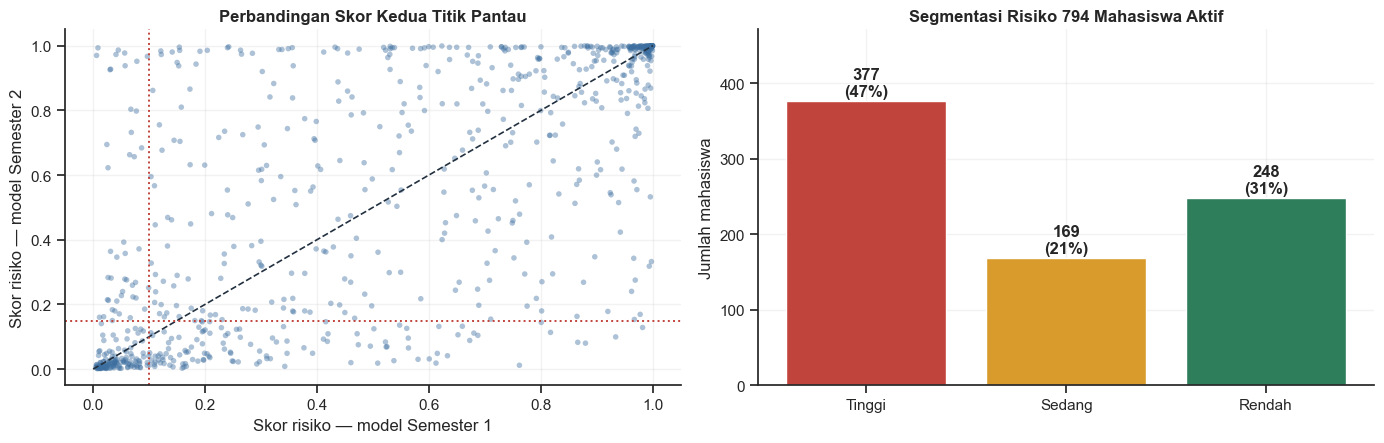

Terdeteksi baru di semester 2 (aman di semester 1) : 45 mahasiswa
Membaik dan keluar dari daftar risiko               : 119 mahasiswa

Estimasi pendapatan berisiko (tingkat Tinggi) : Rp11,310,000,000


In [27]:
skor_aktif = {cp: MODEL_FINAL[cp].predict_proba(siapkan_X(df_aktif, cp))[:, 1]
              for cp in (1, 2)}

aktif = df_aktif.copy()
aktif['risiko_sem1'] = skor_aktif[1].round(4)
aktif['risiko_sem2'] = skor_aktif[2].round(4)
aktif['tingkat'] = pd.cut(skor_aktif[2], [-0.01, AMBANG[2], 0.60, 1.01],
                          labels=['Rendah', 'Sedang', 'Tinggi'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].scatter(skor_aktif[1], skor_aktif[2], s=16, alpha=0.42, color=COOL,
                edgecolor='none')
axes[0].plot([0, 1], [0, 1], ls='--', color=INK, lw=1.2)
axes[0].axhline(AMBANG[2], ls=':', color=RISK, lw=1.4)
axes[0].axvline(AMBANG[1], ls=':', color=RISK, lw=1.4)
axes[0].set_xlabel('Skor risiko — model Semester 1')
axes[0].set_ylabel('Skor risiko — model Semester 2')
axes[0].set_title('Perbandingan Skor Kedua Titik Pantau', fontweight='bold')

jml = aktif['tingkat'].value_counts().reindex(['Tinggi', 'Sedang', 'Rendah'])
bars = axes[1].bar(jml.index, jml.values, color=[RISK, WARN, SAFE], edgecolor='white')
for b, v in zip(bars, jml.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 6, f'{v}\n({v/len(aktif):.0%})',
                 ha='center', fontweight='bold')
axes[1].set_ylim(0, jml.max() * 1.25)
axes[1].set_ylabel('Jumlah mahasiswa')
axes[1].set_title('Segmentasi Risiko 794 Mahasiswa Aktif', fontweight='bold')
sns.despine(); plt.tight_layout(); plt.show()

naik = ((skor_aktif[2] >= AMBANG[2]) & (skor_aktif[1] < AMBANG[1])).sum()
turun = ((skor_aktif[2] < AMBANG[2]) & (skor_aktif[1] >= AMBANG[1])).sum()
print(f'Terdeteksi baru di semester 2 (aman di semester 1) : {naik} mahasiswa')
print(f'Membaik dan keluar dari daftar risiko               : {turun} mahasiswa')
print(f'\nEstimasi pendapatan berisiko (tingkat Tinggi) : '
      f'Rp{jml["Tinggi"] * RUGI_DROPOUT:,}')

> **Insight:** Kedua model **tidak sekadar mengulang penilaian yang sama**. Dari 794 mahasiswa aktif,
> **45 orang** yang tampak aman menurut model semester 1 naik melewati ambang batas pada model
> semester 2 — persis kelompok tersembunyi yang ditemukan pada tahap EDA. Sebaliknya **119 orang**
> membaik dan keluar dari daftar risiko.
>
> Segmentasinya: **377 mahasiswa (47%) berisiko tinggi**, 169 sedang, dan 248 rendah. Dengan asumsi
> kerugian Rp30 juta per mahasiswa, kelompok berisiko tinggi merepresentasikan **sekitar Rp11,3 miliar
> pendapatan yang dipertaruhkan** — angka yang membuat pembiayaan program bimbingan mudah
> dipertanggungjawabkan di hadapan manajemen.
>
> Inilah alasan sistem dua titik pantau lebih unggul daripada satu prediksi sekali jalan:
> **status risiko seorang mahasiswa bukan label permanen, melainkan sesuatu yang perlu dinilai
> ulang setiap semester.**

### Menyiapkan data untuk Business Dashboard

Berkas dashboard dibuat **setelah** pemodelan, karena selain data historis berlabel manusiawi, berkas
ini juga memuat **skor risiko hasil model** untuk seluruh mahasiswa. Dengan begitu dashboard tidak
berhenti pada laporan masa lalu, tetapi sekaligus menampilkan proyeksi risiko yang sedang berjalan.

In [28]:
dash = df.copy()

# Label manusiawi
dash['prodi']        = dash['Course'].map(MAP_COURSE)
dash['status_spp']   = dash['Tuition_fees_up_to_date'].map(MAP_SPP)
dash['kelas']        = dash['Daytime_evening_attendance'].map(MAP_KELAS)
dash['gender']       = dash['Gender'].map(MAP_GENDER)
dash['beasiswa']     = dash['Scholarship_holder'].map(MAP_YA_TIDAK)
dash['debitur']      = dash['Debtor'].map(MAP_YA_TIDAK)
dash['pernikahan']   = dash['Marital_status'].map(MAP_MARITAL)
dash['kelompok_usia'] = pd.cut(dash['Age_at_enrollment'], [0, 20, 25, 30, 40, 100],
                               labels=['<=20 th', '21-25 th', '26-30 th', '31-40 th', '>40 th'])

# Kolom progresi
dash['sel_progresi'] = ('Sem1 ' + dash['band_sem1'].astype(str)
                        + ' -> Sem2 ' + dash['band_sem2'].astype(str))
dash['arah_progresi'] = np.select(
    [dash['rasio_sem2'] > dash['rasio_sem1'] + 0.05,
     dash['rasio_sem2'] < dash['rasio_sem1'] - 0.05],
    ['Membaik', 'Memburuk'], default='Stabil')
dash['kelompok_tersembunyi'] = np.where(
    (dash['rasio_sem1'] >= 0.5) & (dash['rasio_sem2'] < 0.5), 'Ya', 'Tidak')
dash['tahap_funnel'] = np.select(
    [dash['rasio_sem1'] < 0.5,
     (dash['rasio_sem1'] >= 0.5) & (dash['rasio_sem2'] < 0.5)],
    ['1. Gugur di Semester 1', '2. Gugur di Semester 2'],
    default='3. Lolos Dua Semester')
dash['is_dropout'] = (dash['Status'] == 'Dropout').astype(int)

# Skor risiko dari model, untuk SELURUH mahasiswa
dash['risiko_sem1'] = MODEL_FINAL[1].predict_proba(siapkan_X(dash, 1))[:, 1].round(4)
dash['risiko_sem2'] = MODEL_FINAL[2].predict_proba(siapkan_X(dash, 2))[:, 1].round(4)
dash['tingkat_risiko'] = pd.cut(dash['risiko_sem2'], [-0.01, AMBANG[2], 0.60, 1.01],
                                labels=['Rendah', 'Sedang', 'Tinggi'])
dash['pendapatan_berisiko'] = np.where(dash['Status'] == 'Enrolled',
                                       dash['risiko_sem2'] * RUGI_DROPOUT, 0).round(0)

os.makedirs('dashboard', exist_ok=True)
dash.to_csv('dashboard/mahasiswa_dashboard.csv', index=False)
print(f'Tersimpan: dashboard/mahasiswa_dashboard.csv '
      f'({dash.shape[0]:,} baris x {dash.shape[1]} kolom)')
dash[['prodi', 'tahap_funnel', 'arah_progresi', 'kelompok_tersembunyi',
      'risiko_sem2', 'tingkat_risiko', 'Status']].head()

Tersimpan: dashboard/mahasiswa_dashboard.csv (4,424 baris x 59 kolom)


,prodi,tahap_funnel,arah_progresi,kelompok_tersembunyi,risiko_sem2,tingkat_risiko,Status
0,Animation & Multimedia,1. Gugur di Semester 1,Stabil,Tidak,0.9044,Tinggi,Dropout
1,Tourism,3. Lolos Dua Semester,Stabil,Tidak,0.0683,Rendah,Graduate
2,Communication Design,1. Gugur di Semester 1,Stabil,Tidak,0.9993,Tinggi,Dropout
3,Journalism & Comm,3. Lolos Dua Semester,Memburuk,Tidak,0.0790,Rendah,Graduate
4,Social Service (malam),3. Lolos Dua Semester,Membaik,Tidak,0.0166,Rendah,Graduate


---

## Conclusion

### Menjawab permasalahan bisnis Jaya Jaya Institut

**1. Deteksi selalu terlambat — kini bisa dilakukan sejak akhir tahun pertama.**
Model titik pantau semester 1 menangkap **92,6% mahasiswa yang akan *dropout*** hanya dengan data
yang sudah tersedia beberapa bulan setelah mereka masuk. Institusi tidak perlu menunggu satu tahun
penuh, apalagi menunggu surat pengunduran diri.

**2. Kapan titik pantau paling efektif — pertanyaan ini kini terjawab dengan angka.**
Menambah data satu semester hanya menaikkan ROC-AUC dari **0,940 ke 0,956** (sekitar 0,016), dan
kemampuan mendeteksi praktis tidak berubah (recall 92,6% vs 92,2%). Yang benar-benar meningkat adalah
**precision: 68,3% menjadi 80,4%**. Kesimpulannya bukan memilih salah satu, melainkan memakai
keduanya dengan peran berbeda:

| Titik pantau | Kekuatan | Peran operasional |
|---|---|---|
| **Akhir Semester 1** | Recall 92,6%, waktu bertindak masih panjang | **Penyaringan luas** — kontak ringan, undangan tutoring, pengecekan kondisi finansial |
| **Akhir Semester 2** | Precision 80,4%, daftar jauh lebih bersih | **Penanganan intensif** — konseling wajib, restrukturisasi SPP, kontrak akademik |

**3. Ambang batas kini punya dasar ekonomi, bukan kebiasaan.**
Melalui minimisasi ekspektasi biaya diperoleh ambang **0,10** (semester 1) dan **0,15** (semester 2),
konsisten dengan nilai teoretis 0,125. Uji sensitivitas menunjukkan ambang **semester 2 kokoh**
(bertahan di rentang 0,15–0,375 di seluruh skenario), sementara ambang **semester 1 jauh lebih peka**
terhadap asumsi (0,075–0,550) — temuan yang menentukan urutan penerapan pada rekomendasi di bawah.
Dibanding kondisi tanpa model, ekspektasi kerugian institusi turun sekitar **30%**.

**4. Prioritas kini terukur.** Dari 794 mahasiswa aktif, model memberi skor risiko individual
sehingga tim bimbingan dapat mengurutkan penanganan, bukan menghadapi daftar yang tidak berujung.

### Temuan analitis yang paling menentukan

**Ada kelompok berisiko yang tidak terlihat bila hanya memantau semester 1.**
Sebanyak **272 mahasiswa (8,0% dari yang lolos semester 1)** melewati semester pertama dengan baik
lalu anjlok di semester 2 — dan **68,8% di antaranya *dropout***, hampir lima kali lipat dibanding
**14,0%** pada mereka yang bertahan kuat. Kelompok ini menjadi alasan utama mengapa pemantauan tidak boleh berhenti setelah
satu semester.

**Pemulihan itu nyata, sehingga intervensi layak dibiayai.**
Dari mahasiswa yang lemah di semester 1, sebagian berhasil bangkit di semester 2 dan dropout rate
mereka turun dari **81,3% menjadi 34,9%** — kurang dari separuhnya. Ini bukti empiris bahwa hasil akhir masih bisa diubah —
justifikasi paling kuat untuk mendanai program bimbingan.

**Prestasi akademik tidak melindungi dari masalah keuangan.**
Mahasiswa dengan rasio kelulusan di atas 80% memiliki dropout rate **8,6%** bila SPP lunas, tetapi
**54,8%** bila menunggak — enam kali lipat, dan lebih tinggi daripada mahasiswa berperforma sedang
yang keuangannya lancar (30,3%). Jalur risiko
akademik dan finansial berjalan terpisah dan menuntut dua program penanganan yang berbeda.

**Seluruh data yang dibutuhkan sudah dimiliki institusi.** Model hanya memakai kolom yang sudah ada
di sistem akademik dan keuangan. Tidak diperlukan survei, instrumen, atau pengumpulan data baru.

### Rekomendasi Action Items

1. **Mulai dari titik pantau semester 2, lalu tambahkan semester 1 setelah asumsi biaya terverifikasi.**
   Uji sensitivitas menunjukkan ambang semester 2 (0,15) kokoh di seluruh skenario, sedangkan ambang
   semester 1 bergerak lebar (0,075–0,550). Karena itu jalankan lebih dulu siklus semester 2 dengan
   **penanganan intensif** (konseling wajib, restrukturisasi SPP) bagi mahasiswa di atas ambang 0,15.
   Setelah nilai `B` dan `p` yang sebenarnya diketahui (lihat butir 5), aktifkan siklus semester 1
   dengan **kontak ringan** — undangan tutoring dan pengecekan kondisi finansial — pada minggu ke-2
   setelah nilai keluar. Membedakan bobot tindak lanjut inilah yang membuat *precision* 68% di
   semester 1 tetap dapat diterima secara operasional.

2. **Jadikan penurunan rasio kelulusan sebagai pemicu otomatis, terlepas dari nilai absolutnya.**
   Kelompok "kuat lalu jatuh" memiliki dropout rate 68,8% dan tidak akan tertangkap oleh aturan
   berbasis ambang nilai. Kolom `arah_progresi` pada dashboard sudah menyediakan sinyal ini —
   setiap mahasiswa berstatus **"Memburuk"** wajib dihubungi dosen wali, meskipun nilainya masih
   di atas batas kelulusan.

3. **Pisahkan program intervensi finansial dari intervensi akademik.**
   Karena mahasiswa berprestasi pun rentan ketika menunggak, jalankan **skema cicilan otomatis tanpa
   denda** yang dipicu sejak keterlambatan pembayaran pertama — tanpa mensyaratkan nilai akademik
   tertentu, dan tanpa memblokir akses akademik yang justru mempercepat *dropout*.

4. **Ganti asumsi biaya dengan angka riil institusi, lalu jalankan ulang analisis ambang batas.**
   Nilai `R`, `B`, dan `p` yang dipakai bersifat ilustratif. Bagian *Uji sensitivitas* pada notebook
   ini dapat langsung dijalankan ulang dengan angka keuangan sebenarnya untuk memperoleh ambang batas
   yang paling tepat bagi institusi.

5. **Ukur peluang keberhasilan intervensi (`p`) melalui pencatatan yang disiplin.**
   Parameter ini paling menentukan ambang batas namun paling tidak diketahui. Catat setiap intervensi
   beserta hasilnya selama satu tahun ajaran, lalu hitung `p` sesungguhnya. Institusi akan memperoleh
   sistem yang mengkalibrasi dirinya sendiri.

6. **Prioritaskan program studi berdasarkan rasio kelulusan semester 1, bukan menunggu angka dropout.**
   Hubungan keduanya nyaris linear, sementara rasio kelulusan sudah diketahui beberapa bulan setelah
   mahasiswa masuk — sedangkan angka *dropout* baru muncul bertahun-tahun kemudian. Prodi seperti
   *Biofuel Production Technologies*, *Equinculture*, dan *Informatics Engineering* perlu evaluasi
   mata kuliah dasar dan penambahan dosen wali.

7. **Latih ulang kedua model setiap tahun ajaran** dengan data angkatan terbaru, dan pantau apakah
   *recall* pada data angkatan berjalan masih bertahan di kisaran 90%. Penurunan yang konsisten
   menandakan profil mahasiswa telah berubah dan model perlu ditinjau.